# Step 1: Import Required Libraries

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score

## Step 2: Load Dataset

In [67]:
insurance_df = pd.read_csv("insurance.csv")
df_copy = insurance_df
insurance_df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.92
1,18,male,33.77,1,no,southeast,1725.55
2,28,male,33.00,3,no,southeast,4449.46
3,33,male,22.70,0,no,northwest,21984.47
4,32,male,28.88,0,no,northwest,3866.86



## Step 3: Understand the Dataset


In [68]:
insurance_df.shape

(1338, 7)

In [69]:
insurance_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [70]:
insurance_df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [71]:
insurance_df.describe()

,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,39.21,30.66,1.09,13270.42
std,14.05,6.10,1.21,12110.01
min,18.00,15.96,0.00,1121.87
25%,27.00,26.30,0.00,4740.29
50%,39.00,30.40,1.00,9382.03
75%,51.00,34.69,2.00,16639.91
max,64.00,53.13,5.00,63770.43



## Step 4: Exploratory Data Analysis (EDA)

Distribution of Charges

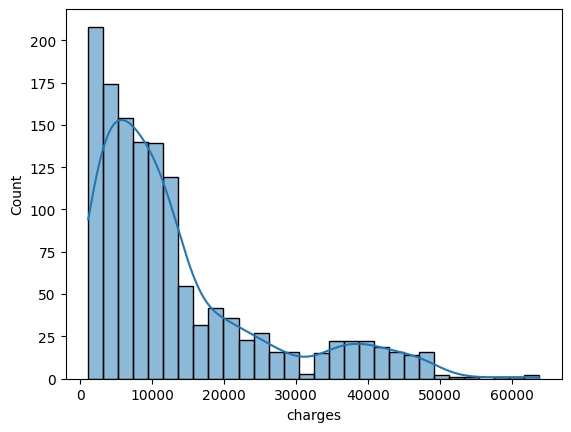

In [72]:
sns.histplot(
    insurance_df['charges'],
    kde=True
)
plt.show()

Charges by Smoking Status

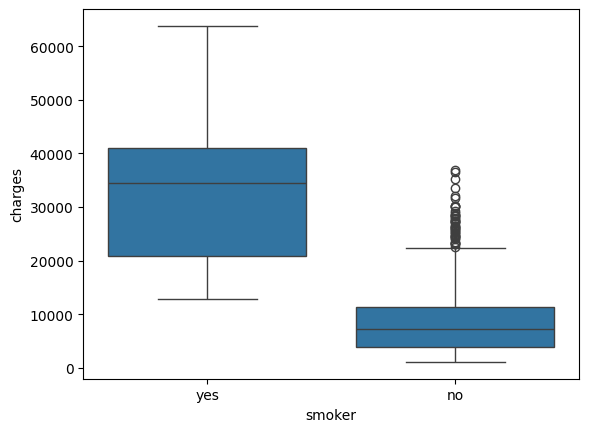

In [73]:
sns.boxplot(
    x='smoker',
    y='charges',
    data=insurance_df
)
plt.show()

Observation:
Smokers incur significantly higher medical charges.

Age vs Charges

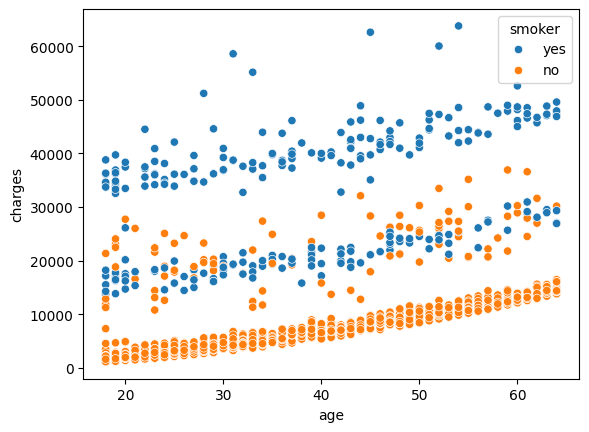

In [74]:
sns.scatterplot(
    data=insurance_df,
    x='age',
    y='charges',
    hue='smoker'
)
plt.show()

Observation:
Charges generally increase with age.

BMI vs Charges

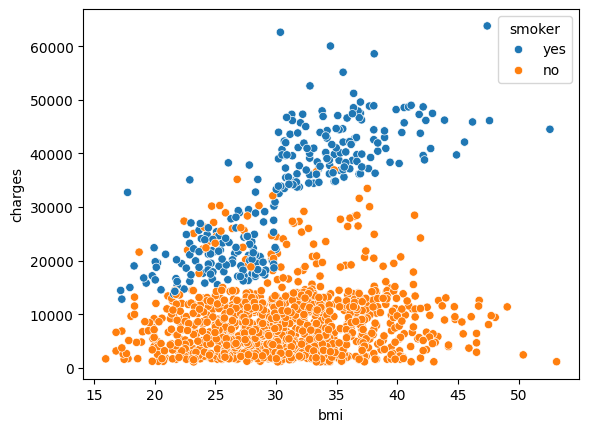

In [75]:
sns.scatterplot(
    data=insurance_df,
    x='bmi',
    y='charges',
    hue='smoker'
)
plt.show()

Observation:
The scatter plot indicates that smokers incur significantly higher medical insurance charges than non-smokers. While BMI shows a positive relationship with charges, its effect is much stronger among smokers. Individuals who both smoke and have higher BMI values tend to experience the highest insurance costs. This suggests that smoking status and BMI are important predictors of insurance charges and may interact to influence medical expenses.

Outlier Analysis

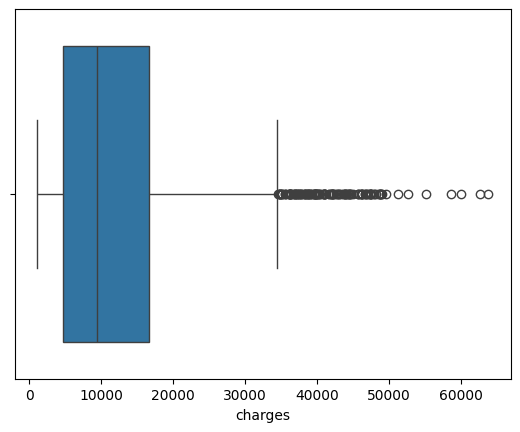

In [76]:
sns.boxplot(x=insurance_df['charges'])
plt.show()

Observation:
Some high-value charges exist but appear to be legitimate observations rather than data entry errors.

## Feature engineering

In [77]:
# One Hot Encoding
encoded_df = pd.get_dummies(insurance_df, drop_first=True, dtype=int)

encoded_df.head() # although get_dummies() may display True/False, they are effectively binary numeric features (0/1),
# which is exactly what regression and classification algorithms need.

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.90,0,16884.92,0,1,0,0,1
1,18,33.77,1,1725.55,1,0,0,1,0
2,28,33.00,3,4449.46,1,0,0,1,0
3,33,22.70,0,21984.47,1,0,1,0,0
4,32,28.88,0,3866.86,1,0,1,0,0


## Correlation Analysis

In [78]:
encoded_df.corr()['charges'].sort_values(ascending=False)

charges             1.00
smoker_yes          0.79
age                 0.30
bmi                 0.20
region_southeast    0.07
children            0.07
sex_male            0.06
region_northwest   -0.04
region_southwest   -0.04
Name: charges, dtype: float64

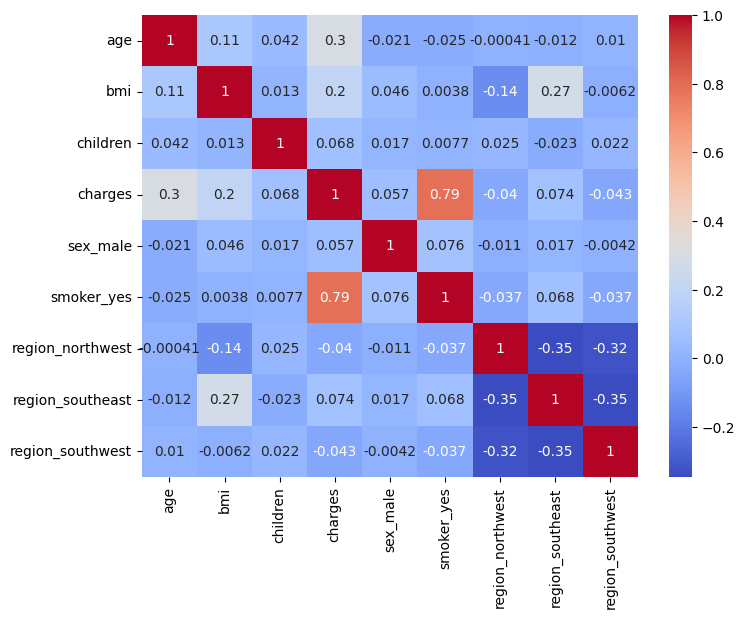

In [79]:
plt.figure(figsize=(8,6))

sns.heatmap(
    encoded_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

## Step 5: Define Features and Target

### Features (X)
Independent variables used for prediction.

### Target (Y)
Dependent variable to predict.

In [80]:

# Features (Independent Variables)

x = encoded_df.drop('charges', axis =1)
x

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.90,0,0,1,0,0,1
1,18,33.77,1,1,0,0,1,0
2,28,33.00,3,1,0,0,1,0
3,33,22.70,0,1,0,1,0,0
4,32,28.88,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...
1333,50,30.97,3,1,0,1,0,0
1334,18,31.92,0,0,0,0,0,0
1335,18,36.85,0,0,0,0,1,0
1336,21,25.80,0,0,0,0,0,1


In [81]:

# Target (Dependent Variable)

y = encoded_df['charges']
y

0      16884.92
1       1725.55
2       4449.46
3      21984.47
4       3866.86
         ...   
1333   10600.55
1334    2205.98
1335    1629.83
1336    2007.94
1337   29141.36
Name: charges, Length: 1338, dtype: float64


## Step 6: Split Dataset into Training and Testing Data

### Why?
- Training data is used to train the model.
- Testing data is used to evaluate the model.

### test_size = 0.2
20% of data is used for testing.

In [82]:
# split the dataset

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

# Check shapes

print('x_train shape: ', x_train.shape)
print('x_test shape: ', x_test.shape)

x_train shape:  (1070, 8)
x_test shape:  (268, 8)


## Step 7: Build Linear Regression Model

In [83]:
# Create model
model =LinearRegression()

# Train model

model.fit(x_train,y_train)

#Scikit-learn converts the data into NumPy arrays because arrays are much faster for calculations.


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False



## Step 8: Model Prediction


In [84]:
# Predict using test data

y_pred = model.predict(x_test)

# Display predictions

print(y_pred[:5]) # the values are in array

[ 8969.55027444  7068.74744287 36858.41091155  9454.67850053
 26973.17345656]



## Step 9: Evaluation Metrics

### MAE - Mean Absolute Error
Average absolute difference between actual and predicted values.

### MSE - Mean Squared Error
Average squared difference.

### RMSE - Root Mean Squared Error
Square root of MSE.

### R² Score
How well the model explains the data.

In [85]:

# Calculate evaluation metrics

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

# Print metrics

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


MAE: 4181.194473753649
MSE: 33596915.85136145
RMSE: 5796.284659276273
R2 Score: 0.7835929767120724


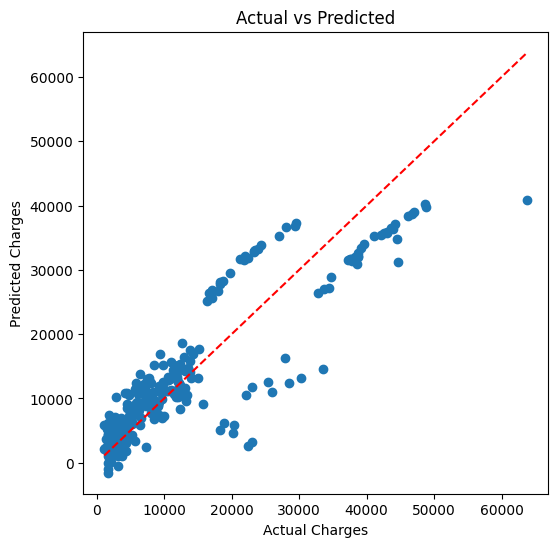

In [86]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted")
plt.show()


## Step 10: Compare Actual vs Predicted Values


In [87]:

# Create comparison dataframe
# Remove scientific notation

pd.options.display.float_format = '{:.2f}'.format


comparison = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred
})

comparison.head(10)


,Actual Price,Predicted Price
764,9095.07,8969.55
887,5272.18,7068.75
890,29330.98,36858.41
1293,9301.89,9454.68
259,33750.29,26973.17
1312,4536.26,10864.11
899,2117.34,170.28
752,14210.54,16903.45
1286,3732.63,1092.43
707,10264.44,11218.34



## Step 11: Predict Charges for New person


In [88]:
new_person = pd.DataFrame({
    'age':[30],
    'bmi':[28.5],
    'children':[2],
    'sex_male':[1],
    'smoker_yes':[0],
    'region_northwest':[0],
    'region_southeast':[1],
    'region_southwest':[0]
})

prediction = model.predict(new_person)

print("Predicted Charges:", prediction[0])

Predicted Charges: 5559.291433992266


In [89]:
print("Actual Price:", y_test.iloc[0])
print("Predicted Price:", prediction[0])

Actual Price: 9095.06825
Predicted Price: 5559.291433992266


Summary:
A Linear Regression model was trained to predict insurance charges using age, BMI, children, sex, smoker status, and region. The model achieved an R² score of 0.784, indicating that approximately 78.4% of the variance in charges was explained by the selected features. Smoking status showed the strongest correlation with charges, followed by age and BMI. The model provides a solid baseline, though more advanced algorithms such as Random Forest may further improve predictive performance.

In [90]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

In [91]:
mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf
    )
)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

# Print metrics

print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

MAE: 2550.0784706115096
RMSE: 4576.299916157115
R2 Score: 0.8651034329144947


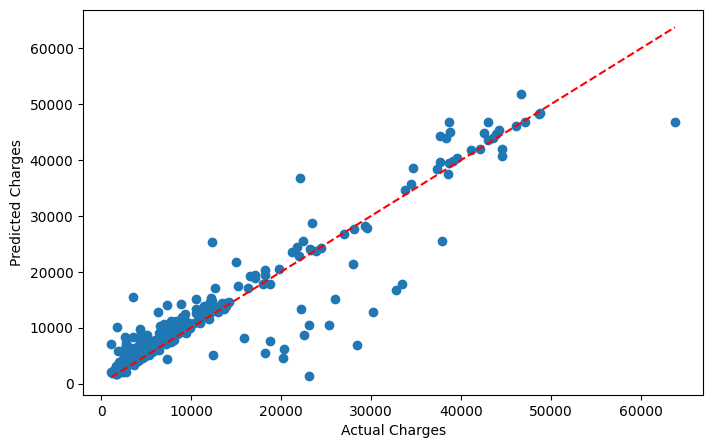

In [92]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    y_pred_rf
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')

plt.show()

## Feature Importance

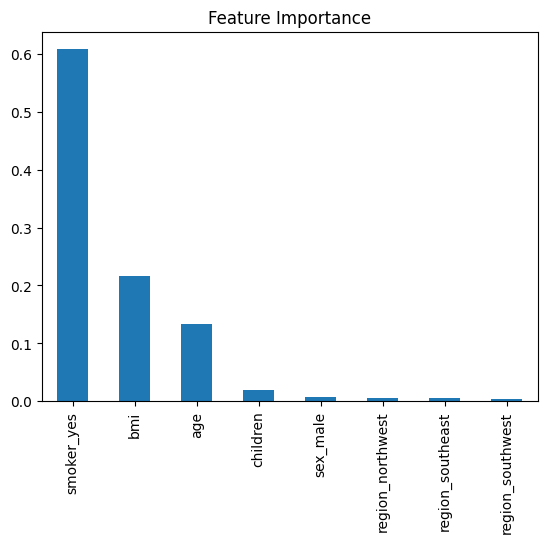

In [93]:
importance = pd.Series(
    rf.feature_importances_,
    index=x_train.columns
)

importance.sort_values(
    ascending=False
).plot(
    kind='bar'
)

plt.title(
    'Feature Importance'
)

plt.show()

# Final Observation: 

A Linear Regression model was initially trained to predict insurance charges using age, BMI, number of children, sex, smoker status, and region. The model achieved an R² score of 0.784, indicating that approximately 78.4% of the variance in insurance charges was explained by the selected features. Exploratory Data Analysis revealed that smoking status had the strongest correlation with charges, followed by age and BMI.

To improve predictive performance, a Random Forest Regressor was implemented. The Random Forest model achieved an R² score of 0.865, outperforming the Linear Regression model and explaining approximately 86.5% of the variance in insurance charges. The improvement suggests that the dataset contains non-linear relationships that are better captured by an ensemble tree-based model. Therefore, the Random Forest Regressor was selected as the preferred model for predicting insurance charges.

## Conclusion:

Smoking status is the strongest predictor of insurance charges.

Age and BMI also contribute significantly.

Linear Regression provided a solid baseline performance.

Random Forest captured non-linear relationships more effectively and improved prediction accuracy.

The Random Forest Regressor was selected as the final model with an R² score of 0.865.